# Assignment 5: 

Please compare the PI from initial project layout and the new optimized project layout.

Better to non dimensonalize the input and output parameters

# Importing Modules

In [177]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import netCDF4 as nc_lib
from scipy.optimize import minimize
from scipy.special import gamma
import warnings
warnings.filterwarnings("ignore")

from floris import FlorisModel, WindRose
import yaml as _yaml

from windrose import WindroseAxes

import floris, pathlib

import netCDF4 as nc_lib
import numpy as np

import requests, tempfile, os
import netCDF4 as nc_lib
import numpy as np
from windrose import WindroseAxes
import matplotlib.pyplot as plt
from floris import TimeSeries, WindRose

# Inputs

## Turbine Inputs

In [178]:
D			= 130.0			# Rotor diameter [m]
HUB_H		= 120.0			# Hub height [m]
ALPHA		= 0.20			# Wind shear exponent
TI			= 0.06			# Turbulence intensity
N_TURB		= 8				# Number of turbines
P_RATED_KW	= 3370.0		# Rated power per turbine [kW]
P_RATED_MW	= P_RATED_KW / 1e3
windshear = 0.14

## Boundaries

In [179]:
BOUND      = 2800.0
SUBSTATION = np.array([BOUND/2, BOUND/2])   # centre
MIN_SEP    = 2 * D                           # 260 m

## Financial Parameters

In [180]:
DISCOUNT_RATE    = 0.04			# nominal
TURBINE_COST_MW  = 1.3e6		# $/MW
OM_COST_KWH      = 0.016		# $/kWh
RENTAL_COST_MW_Y = 20_000       # $/MW·yr
FUEL_COST_GAL    = 5.19			# USD/gal (diesel for installation vessel)
ELEC_PRICE       = 67.0			# $/MWh
PROJECT_LIFE     = 20			# years
HOURS_YR         = 8760

## File Locations

In [181]:
NC_FILE = "/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment5/microclimate-Area 2.nc"

default_yaml = r"/home/lavender/Studies/Design of Wind Farms/.venv/lib64/python3.12/site-packages/floris/default_inputs.yaml"

gchyaml = r"/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment5/gch.yaml"

# 1. Wind Data Processing

## Using NEWA API to Pull Data

In [182]:
# Nearest grid point to Marienplatz Munich (as seen on NEWA Website)
LAT = 48.136079
LON = 11.579247

NEWA_URL = (
    "https://newa-api.ramtt.xyz/api/mesoscale-ts/v1/get-data-point"
    f"?latitude={LAT}"
    f"&longitude={LON}"
    "&variable=WD10"
    "&variable=WS10"
    "&dt_start=2000-01-01T00:00:00"
    "&dt_stop=2022-12-31T23:30:00"
)

print("Downloading NEWA mesoscale time series … (this may take 1-2 min)")
print(f"  URL: {NEWA_URL}")
response = requests.get(NEWA_URL, timeout=300)
response.raise_for_status()

tmp_nc = tempfile.NamedTemporaryFile(suffix=".nc", delete=False)
tmp_nc.write(response.content)
tmp_nc.close()
print(f"  Downloaded {len(response.content)/1e6:.1f} MB  →  {tmp_nc.name}")

  URL: https://newa-api.ramtt.xyz/api/mesoscale-ts/v1/get-data-point?latitude=48.136079&longitude=11.579247&variable=WD10&variable=WS10&dt_start=2000-01-01T00:00:00&dt_stop=2022-12-31T23:30:00
  Downloaded 4.9 MB  →  /tmp/tmpneutfhf7.nc


## Load Variables

In [183]:
ds = nc_lib.Dataset(tmp_nc.name)
print("Variables in file:", list(ds.variables.keys()))

ws_raw_10m = np.array(ds.variables["WS10"][:]).ravel()   # [m/s]
wd_raw     = np.array(ds.variables["WD10"][:]).ravel()   # [°]
lat_actual = float(np.array(ds.variables["XLAT"][:]).mean())
lon_actual = float(np.array(ds.variables["XLON"][:]).mean())

ds.close()
os.unlink(tmp_nc.name)

print(f"  Grid point     : {lat_actual:.4f}°N  {lon_actual:.4f}°E")
print(f"  Time steps     : {len(ws_raw_10m):,}  ({len(ws_raw_10m)/8760:.1f} years)")
print(f"  Mean WS at 10 m: {ws_raw_10m.mean():.2f} m/s")

Variables in file: ['WD10', 'WS10', 'time', 'XLAT', 'XLON', 'crs', 'south_north', 'west_east']
  Grid point     : 48.1404°N  11.5684°E
  Time steps     : 403,248  (46.0 years)
  Mean WS at 10 m: 4.00 m/s


## Scale from 10m to HUB_H

In [184]:
H_MEAS = 10.0
ws_hub = ws_raw_10m * (HUB_H / H_MEAS) ** ALPHA
print(f"  Mean WS at {HUB_H:.0f} m : {ws_hub.mean():.2f} m/s  (α = {ALPHA})")

  Mean WS at 120 m : 6.58 m/s  (α = 0.2)


## Build FLORIS WindRose

In [185]:
ti_array = np.full(len(ws_hub), TI)

time_series = TimeSeries(
    wind_directions=wd_raw,
    wind_speeds=ws_hub,
    turbulence_intensities=ti_array,
)

wind_rose = time_series.to_WindRose(wd_step=30.0, ws_step=1.0)

## Plot

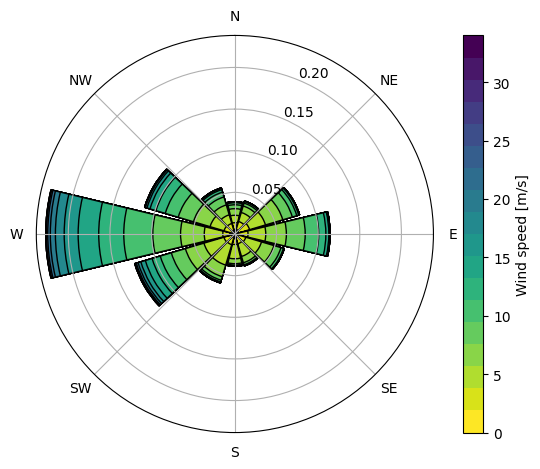

In [186]:
wind_rose = time_series.to_WindRose(wd_step=30.0, ws_step=1.0)

wind_rose.plot(wd_step=30, ws_step=2)

plt.savefig('wind_rose.png', dpi=150, bbox_inches='tight')

# 2. Evaluate Farm Properties

## Initial layout

In [187]:
# Initial layout (from assignment figure: 4×2 grid, rows at y≈1.2 & 1.6 km)
x_init = np.array([0, 0, 0, 0,
				   BOUND, BOUND, BOUND, BOUND])   # [m]
y_init = np.array([0, BOUND/4, BOUND/2, BOUND*3/4,
				   0, BOUND/4, BOUND/2, BOUND*3/4,])   # [m]

## FLORIS configuration (load default and patch)

In [188]:
with open(gchyaml) as _f:
	fmodel_dict = _yaml.safe_load(_f)

fmodel_dict["farm"]["layout_x"] = x_init
fmodel_dict["farm"]["layout_y"] = y_init
# fmodel_dict["flow_field"][]

fm = FlorisModel(fmodel_dict)
fm.set(layout_x=x_init,layout_y=y_init,wind_data=wind_rose,
           wind_shear=windshear)

fm.run()

In [189]:
fmodel_dict

{'name': 'GCH',
 'description': 'Three turbines using Gauss Curl Hybrid model',
 'floris_version': 'v4',
 'logging': {'console': {'enable': True, 'level': 'WARNING'},
  'file': {'enable': False, 'level': 'WARNING'}},
 'solver': {'type': 'turbine_grid', 'turbine_grid_points': 3},
 'farm': {'layout_x': array([   0.,    0.,    0.,    0., 2800., 2800., 2800., 2800.]),
  'layout_y': array([   0.,  700., 1400., 2100.,    0.,  700., 1400., 2100.]),
  'turbine_type': ['iea_3_4MW']},
 'flow_field': {'air_density': 1.225,
  'reference_wind_height': -1,
  'turbulence_intensities': [0.06],
  'wind_directions': [270.0],
  'wind_shear': 0.12,
  'wind_speeds': [8.0],
  'wind_veer': 0.0,
  'multidim_conditions': {'Tp': 2.5, 'Hs': 3.01}},
 'wake': {'model_strings': {'combination_model': 'sosfs',
   'deflection_model': 'gauss',
   'turbulence_model': 'crespo_hernandez',
   'velocity_model': 'gauss'},
  'enable_secondary_steering': True,
  'enable_yaw_added_recovery': True,
  'enable_active_wake_mixing':

## AEP

In [190]:
fm.set(wind_data=wind_rose)
fm.run()
aep_wh   = fm.get_farm_AEP()   # Wh - uses freq from WindRose automatically
aep_gwh  = aep_wh / 1e9
aep_mwh  = aep_wh / 1e6

print(f"\n  AEP (baseline)            : {aep_gwh:.3f} GWh/yr")

# Capacity factor
p_installed_kw = N_TURB * P_RATED_KW
cf = (aep_mwh * 1e3) / (p_installed_kw * HOURS_YR) * 100
print(f"  Capacity Factor           : {cf:.2f} %")

# Farm efficiency
fmodel_single_dict = fmodel_dict.copy()
fmodel_single = FlorisModel(fm.__dict__["configuration"])
fmodel_single.set(
	layout_x=[0.0],
	layout_y=[0.0],
	wind_data=wind_rose,
)
fmodel_single.run()
aep_single_wh = fmodel_single.get_farm_AEP()   # single turbine AEP
aep_no_wake_wh = aep_single_wh * N_TURB         # ideal (no wake) farm AEP

farm_eff = (aep_wh / aep_no_wake_wh) * 100
print(f"  Farm Efficiency           : {farm_eff:.2f} %")


  AEP (baseline)            : 84.929 GWh/yr
  Capacity Factor           : 35.96 %
  Farm Efficiency           : 96.43 %


## LCoE calculation

In [191]:
def compute_cable_length(layout_x, layout_y, substation=SUBSTATION):
	"""Sum of cable lengths from each turbine to substation [m]."""
	dists = np.sqrt((layout_x - substation[0])**2 + (layout_y - substation[1])**2)
	return dists.sum()

def lcoe_pi(layout_x, layout_y, aep_mwh_yr, p_rated_kw=P_RATED_KW, n=N_TURB):
	"""
	Returns (LCoE [$/MWh], PI) for given layout and AEP.

	Capital cost breakdown:
	 - Turbine cost
	 - Substation cable cost (BOS): approximated from cable length
	Ongoing costs:
	 - O&M:  0.016 $/kWh
	 - Rental: 20,000 $/MW-yr
	"""
	p_rated_mw = p_rated_kw / 1e3

	# CapEx
	turbine_capex = n * p_rated_mw * TURBINE_COST_MW              # $
	# BOS (cables): approx 200 $/m for 30 kV array cable
	cable_cost_per_m = 200.0     # $/m (rough estimate for 30 kV)
	cable_len = compute_cable_length(layout_x, layout_y)
	cable_capex = cable_cost_per_m * cable_len
	total_capex = turbine_capex + cable_capex

	om_per_yr     = OM_COST_KWH * aep_mwh_yr * 1e3   # OM on kWh
	rental_per_yr = RENTAL_COST_MW_Y * n * p_rated_mw

	# Annuity factor  A = r*(1+r)^N / ((1+r)^N - 1)
	r = DISCOUNT_RATE
	N = PROJECT_LIFE
	annuity = r * (1+r)**N / ((1+r)**N - 1)

	# Levelised capital cost per year
	capex_ann = total_capex * annuity

	# Total annual cost
	total_ann_cost = capex_ann + om_per_yr + rental_per_yr

	# LCoE
	lcoe = total_ann_cost / aep_mwh_yr   # $/MWh

	# Revenue per year
	revenue_yr = ELEC_PRICE * aep_mwh_yr

	# NPV of revenues
	npv_revenues = revenue_yr * (1 - (1+r)**(-N)) / r

	# PI = NPV / CapEx
	npv_net = npv_revenues - total_capex - (om_per_yr + rental_per_yr) * (1 - (1+r)**(-N)) / r
	pi = npv_net / total_capex

	return lcoe, pi, total_capex, cable_len

lcoe_base, pi_base, capex_base, cable_base = lcoe_pi(x_init, y_init, aep_mwh)

print(f"\n  Total CapEx               : ${capex_base/1e6:.2f} M")
print(f"  Cable total length        : {cable_base/1e3:.2f} km")
print(f"  LCoE (baseline)           : {lcoe_base:.2f} $/MWh")
print(f"  PI   (baseline)           : {pi_base:.4f}")
print(f"\n\tElectricity price = {ELEC_PRICE} $/MWh")
print(f"\tLCoE {'<' if lcoe_base < ELEC_PRICE else '>'} electricity price  ->  "
	  f"{'PROFITABLE' if lcoe_base < ELEC_PRICE else 'NOT profitable'}")



  Total CapEx               : $37.65 M
  Cable total length        : 13.02 km
  LCoE (baseline)           : 54.97 $/MWh
  PI   (baseline)           : 0.3688

	Electricity price = 67.0 $/MWh
	LCoE < electricity price  ->  PROFITABLE


# 3.  Layout Optimisation  -  minimise LCoE with COBYLA

In [192]:
lcoe_history = []
iter_count   = [0]

def objective(xy_flat):
	"""Return LCoE to be minimised."""
	iter_count[0] += 1
	lx = xy_flat[:N_TURB]
	ly = xy_flat[N_TURB:]

	fm_opt = FlorisModel(fmodel_dict)
	try:
		fm_opt.set(
			layout_x=lx.tolist(),
			layout_y=ly.tolist(),
			wind_data=wind_rose,
		)
		fm_opt.run()
		aep_wh_opt = fm_opt.get_farm_AEP()
		aep_mwh_opt = aep_wh_opt / 1e6
	except Exception:
		aep_mwh_opt = 1.0   # fallback avoids crash

	lcoe_val, _, _, _ = lcoe_pi(lx, ly, aep_mwh_opt)
	lcoe_history.append(lcoe_val)

	if iter_count[0] % 50 == 0:
		print(f"    iter {iter_count[0]:4d}  LCoE = {lcoe_val:.4f} $/MWh")
	return lcoe_val

## Constraints

In [193]:
def make_constraints(n=N_TURB, d_min=MIN_SEP, bound=BOUND):
	constraints = []

	# Boundary constraints: 0 ≤ x,y ≤ BOUND  (expressed as ≥ 0)
	for i in range(n):
		constraints.append({"type": "ineq", "fun": lambda xy, i=i: xy[i]})          # x ≥ 0
		constraints.append({"type": "ineq", "fun": lambda xy, i=i: bound - xy[i]})  # x ≤ bound
		constraints.append({"type": "ineq", "fun": lambda xy, i=i: xy[n+i]})        # y ≥ 0
		constraints.append({"type": "ineq", "fun": lambda xy, i=i: bound - xy[n+i]})# y ≤ bound

	# Minimum separation constraints between every turbine pair
	for i in range(n):
		for j in range(i+1, n):
			def sep_con(xy, i=i, j=j):
				dx = xy[i] - xy[j]
				dy = xy[n+i] - xy[n+j]
				return np.sqrt(dx**2 + dy**2) - d_min
			constraints.append({"type": "ineq", "fun": sep_con})

	return constraints

constraints = make_constraints()

x0 = np.concatenate([x_init, y_init])

print(f"\n  Initial LCoE: {objective(x0):.4f} $/MWh  (counts as iteration 1)")
iter_count[0] = 0   # reset counter

print(f"  Starting COBYLA optimisation …")
result = minimize(
	objective,
	x0,
	method  = "COBYLA",
	constraints = constraints,
	options = {
		"rhobeg" : 2000.0,    # initial step size [m]
		"maxiter": 2000,
		"rhoend" : 1.0,      # final step size [m]
		"catol"  : 1.0,      # constraint tolerance [m]
		"disp"   : True,
	},
)

x_opt = result.x[:N_TURB]
y_opt = result.x[N_TURB:]

print(f"\n  COBYLA status: {result.message}")
print(f"  Total iterations: {iter_count[0]}")


  Initial LCoE: 54.9651 $/MWh  (counts as iteration 1)
  Starting COBYLA optimisation …
    iter   50  LCoE = 53.7410 $/MWh
    iter  100  LCoE = 53.4092 $/MWh
    iter  150  LCoE = 53.2978 $/MWh
    iter  200  LCoE = 53.2270 $/MWh
    iter  250  LCoE = 53.1906 $/MWh
    iter  300  LCoE = 53.1660 $/MWh
    iter  350  LCoE = 53.1423 $/MWh
    iter  400  LCoE = 53.1286 $/MWh
    iter  450  LCoE = 53.0991 $/MWh
    iter  500  LCoE = 53.0878 $/MWh
    iter  550  LCoE = 53.0771 $/MWh
    iter  600  LCoE = 53.0620 $/MWh
    iter  650  LCoE = 53.0547 $/MWh
    iter  700  LCoE = 53.0474 $/MWh
    iter  750  LCoE = 53.0420 $/MWh
    iter  800  LCoE = 53.0360 $/MWh
    iter  850  LCoE = 53.0318 $/MWh
    iter  900  LCoE = 53.0278 $/MWh
    iter  950  LCoE = 53.0245 $/MWh
    iter 1000  LCoE = 53.0211 $/MWh
    iter 1050  LCoE = 53.0192 $/MWh
    iter 1100  LCoE = 53.0166 $/MWh
    iter 1150  LCoE = 53.0140 $/MWh
    iter 1200  LCoE = 53.0128 $/MWh
    iter 1250  LCoE = 53.0098 $/MWh
    iter 13

## Re-evaluate optimised layout

In [194]:
fm_opt = FlorisModel(fmodel_dict)
fm_opt.set(layout_x=x_opt.tolist(), layout_y=y_opt.tolist(), wind_data=wind_rose)
fm_opt.run()
aep_opt_wh  = fm_opt.get_farm_AEP()
aep_opt_mwh = aep_opt_wh / 1e6
aep_opt_gwh = aep_opt_wh / 1e9

cf_opt   = (aep_opt_mwh * 1e3) / (p_installed_kw * HOURS_YR) * 100
eff_opt  = (aep_opt_wh / aep_no_wake_wh) * 100
lcoe_opt, pi_opt, capex_opt, cable_opt = lcoe_pi(x_opt, y_opt, aep_opt_mwh)

# Verify constraints
in_bounds = all(0 <= x_opt[i] <= BOUND and 0 <= y_opt[i] <= BOUND for i in range(N_TURB))
min_dist = np.inf
for i in range(N_TURB):
	for j in range(i+1, N_TURB):
		d = np.sqrt((x_opt[i]-x_opt[j])**2 + (y_opt[i]-y_opt[j])**2)
		min_dist = min(min_dist, d)
print(f"\n  Constraint check:")
print(f"    All turbines in boundary : {in_bounds}")
print(f"    Min separation           : {min_dist:.1f} m  (limit {MIN_SEP:.0f} m)  "
	  f"{'OK' if min_dist >= MIN_SEP - 2 else '✗ VIOLATED'}")


  Constraint check:
    All turbines in boundary : True
    Min separation           : 477.7 m  (limit 260 m)  OK


In [ ]:
from floris import WindRoseWRG

### Summary table

In [195]:
print("\n" + "─" * 55)
print(f"  {'Metric':<28} {'Baseline':>10}  {'Optimised':>10}")
print("─" * 55)
print(f"  {'AEP [GWh/yr]':<28} {aep_gwh:>10.3f}  {aep_opt_gwh:>10.3f}")
print(f"  {'Capacity Factor [%]':<28} {cf:>10.2f}  {cf_opt:>10.2f}")
print(f"  {'Farm Efficiency [%]':<28} {farm_eff:>10.2f}  {eff_opt:>10.2f}")
print(f"  {'LCoE [$/MWh]':<28} {lcoe_base:>10.2f}  {lcoe_opt:>10.2f}")
print(f"  {'PI [-]':<28} {pi_base:>10.4f}  {pi_opt:>10.4f}")
print(f"  {'Cable length [km]':<28} {cable_base/1e3:>10.2f}  {cable_opt/1e3:>10.2f}")
print("─" * 55)
print(f"\n  Optimised LCoE vs electricity price ({ELEC_PRICE} $/MWh):")
print(f"\t{'PROFITABLE' if lcoe_opt < ELEC_PRICE else 'NOT profitable'}")


───────────────────────────────────────────────────────
  Metric                         Baseline   Optimised
───────────────────────────────────────────────────────
  AEP [GWh/yr]                     84.929      87.526
  Capacity Factor [%]               35.96       37.06
  Farm Efficiency [%]               96.43       99.38
  LCoE [$/MWh]                      54.97       53.01
  PI [-]                           0.3688      0.4535
  Cable length [km]                 13.02        8.23
───────────────────────────────────────────────────────

  Optimised LCoE vs electricity price (67.0 $/MWh):
	PROFITABLE


In [196]:
delta_lcoe = lcoe_base - lcoe_opt

delta_lcoe

np.float64(1.961291571591829)

# 4. Plots

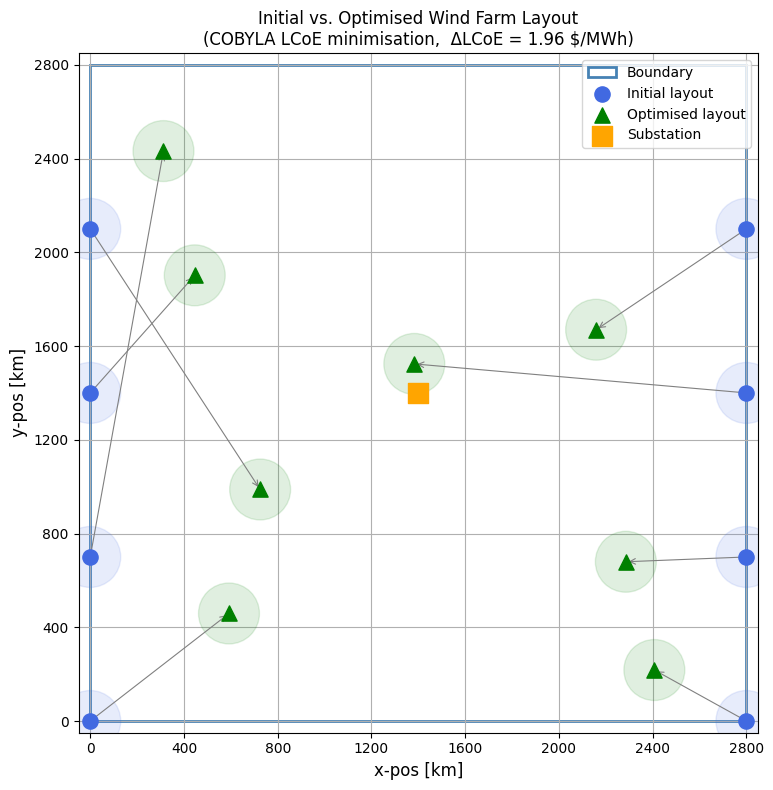

In [197]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.set_xlim(-50, BOUND + 50)
ax.set_ylim(-50, BOUND + 50)

# Boundary
boundary_rect = plt.Rectangle((0,0), BOUND, BOUND,
							   linewidth=2, edgecolor='steelblue',
							   facecolor='none', label='Boundary')
ax.add_patch(boundary_rect)

ax.grid()

# Minimum-separation circles for optimised layout (2D radius)
for i in range(N_TURB):
	circ = plt.Circle((x_opt[i], y_opt[i]), MIN_SEP/2,
					   color='green', alpha=0.12, zorder=2)
	ax.add_patch(circ)
# And for initial layout
for i in range(N_TURB):
	circ = plt.Circle((x_init[i], y_init[i]), MIN_SEP/2,
					   color='royalblue', alpha=0.12, zorder=2)
	ax.add_patch(circ)

# Turbines
ax.scatter(x_init, y_init, s=120, c='royalblue', zorder=5,
		   label='Initial layout', marker='o')
ax.scatter(x_opt,  y_opt,  s=120, c='green',     zorder=5,
		   label='Optimised layout', marker='^')

# Use km axis
ax.set_xlabel("x-pos [km]", fontsize=12)
ax.set_ylabel("y-pos [km]", fontsize=12)

# Substation
ax.scatter(*SUBSTATION, s=200, c='orange', marker='s', zorder=6,
		   label='Substation')

# Arrows: initial to optimised
for i in range(N_TURB):
	ax.annotate("", xy=(x_opt[i], y_opt[i]),
				xytext=(x_init[i], y_init[i]),
				arrowprops=dict(arrowstyle="->", color="gray", lw=0.8))

ax.set_title("Initial vs. Optimised Wind Farm Layout\n"
			 f"(COBYLA LCoE minimisation,  ΔLCoE = {lcoe_base-lcoe_opt:.2f} $/MWh)",
			 fontsize=12)
ax.legend(loc='upper right', fontsize=10)
ax.set_aspect('equal')

# Tick labels in km
ax.set_xticks(np.linspace(0, BOUND, 8))
ax.set_yticks(np.linspace(0, BOUND, 8))

plt.tight_layout()
plt.savefig("/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment5/task3_layout.png", dpi=150, bbox_inches='tight')

## Convergence plot

	Saved: task3_convergence.png


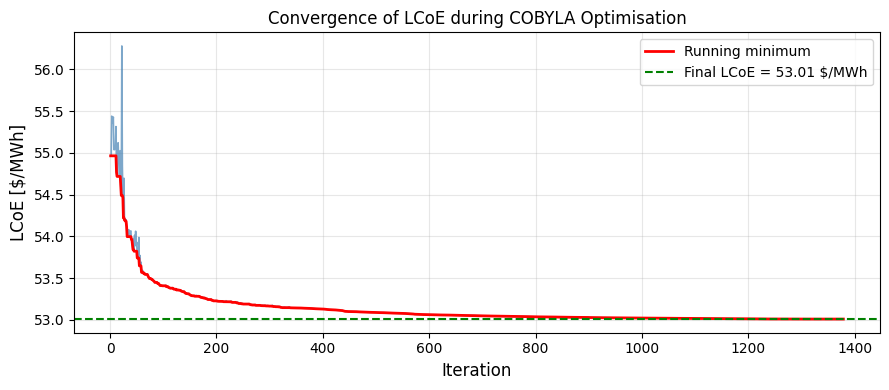

In [198]:
fig, ax = plt.subplots(figsize=(9, 4))
iters = np.arange(1, len(lcoe_history)+1)
ax.plot(iters, lcoe_history, lw=1.2, color='steelblue', alpha=0.7)
# Running minimum (monotone)
running_min = np.minimum.accumulate(lcoe_history)
ax.plot(iters, running_min, lw=2.0, color='red', label='Running minimum')
ax.axhline(lcoe_opt, ls='--', color='green', lw=1.5, label=f'Final LCoE = {lcoe_opt:.2f} $/MWh')
ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("LCoE [$/MWh]", fontsize=12)
ax.set_title("Convergence of LCoE during COBYLA Optimisation", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment5/task3_convergence.png", dpi=150, bbox_inches='tight')
# plt.close()
print("\tSaved: task3_convergence.png")

	Saved: task3_convergence.png


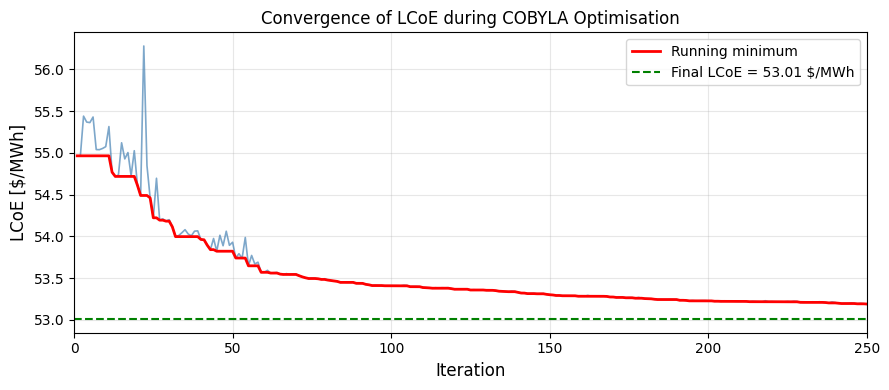

In [199]:
fig, ax = plt.subplots(figsize=(9, 4))
iters = np.arange(1, len(lcoe_history)+1)
ax.plot(iters, lcoe_history, lw=1.2, color='steelblue', alpha=0.7)
# Running minimum (monotone)
running_min = np.minimum.accumulate(lcoe_history)
ax.plot(iters, running_min, lw=2.0, color='red', label='Running minimum')
ax.axhline(lcoe_opt, ls='--', color='green', lw=1.5, label=f'Final LCoE = {lcoe_opt:.2f} $/MWh')
ax.set_xlabel("Iteration", fontsize=12)
ax.set_ylabel("LCoE [$/MWh]", fontsize=12)
ax.set_title("Convergence of LCoE during COBYLA Optimisation", fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(0,250)
plt.tight_layout()
plt.savefig("/home/lavender/Studies/Design of Wind Farms/Assignments/Assignment5/task3_convergence_truncated.png", dpi=150, bbox_inches='tight')
# plt.close()
print("\tSaved: task3_convergence.png")